
# Data Mining Assignment 4 – Classification
## Task 3: Applying the Model to New Instances

---
### 0. Import & Config

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os 
import json
import re
import scipy.sparse
import pickle
import shap

# paths creation need to adapt with yours
path = r'C:\Users\ephts\OneDrive\Documents\Master UA\Data mining\A4' 

data_path = os.path.join(path, 'datas')
preprocessed = os.path.join(path, 'preprocessed')
prediction = os.path.join(path,'prediction_output')
figures = os.path.join(path, 'fig')
os.makedirs(figures, exist_ok=True)
os.makedirs(prediction, exist_ok=True)
print('Imports and paths created')


Imports and paths created


---
### 1. Loading data & model

In [3]:
rf     = pickle.load(open(os.path.join(preprocessed, 'model_rf.pkl'),  'rb'))
scaler = pickle.load(open(os.path.join(preprocessed, 'scaler.pkl'),    'rb'))

with open(os.path.join(preprocessed, 'features.json'), 'r') as f:
    FEATURES = json.load(f)['features']

df_new      = pd.read_csv(os.path.join(data_path, 'income_test.csv'))
df_template = pd.read_csv(os.path.join(data_path, 'predictions_template.csv'))

print(f"New data shape : {df_new.shape}")

New data shape : (2000, 9)


---
## 2. Preprocessing

In [5]:
df_new_model = df_new.copy()

# drop highly missing columns
df_new_model.drop(columns=['ability to speak english'], inplace=True)
df_new_model['gave birth this year'] = df_new_model['gave birth this year'].fillna('No')

# binary categoricals
df_new_model['birth_bin'] = (df_new_model['gave birth this year'] == 'Yes').astype(int)
df_new_model.drop(columns=['gave birth this year'], inplace=True)

#  keep sex for slicing, exclude from features
sex_new = df_new_model['sex'].copy()

# one-hot encoding
df_new_model = pd.get_dummies(df_new_model,
                               columns=['workclass', 'marital status', 'occupation'],
                               drop_first=True)

# align columns with training features
# add missing columns (categories not present in test set)
for col in FEATURES:
    if col not in df_new_model.columns:
        df_new_model[col] = 0

# remove extra columns and reorder
X_new = df_new_model[FEATURES]

print(f"X_new shape    : {X_new.shape}")
print(f"Columns match  : {list(X_new.columns) == FEATURES}")

X_new shape    : (2000, 29)
Columns match  : True


---
### 3. Predictions

In [6]:
y_pred_new   = rf.predict(X_new)
y_proba_new  = rf.predict_proba(X_new)[:, 1]
y_labels_new = pd.Series(y_pred_new).map({0: 'low', 1: 'high'})

print(f"\nPrediction distribution:")
print(y_labels_new.value_counts())
print(f"\nHigh income predicted : {(y_pred_new == 1).sum()} / {len(y_pred_new)} ({(y_pred_new == 1).mean()*100:.1f}%)")
print(f"Low  income predicted : {(y_pred_new == 0).sum()} / {len(y_pred_new)} ({(y_pred_new == 0).mean()*100:.1f}%)")



Prediction distribution:
low     1038
high     962
Name: count, dtype: int64

High income predicted : 962 / 2000 (48.1%)
Low  income predicted : 1038 / 2000 (51.9%)


---
### 4. Gender fairness on new data 

In [7]:
mask_male_new   = (sex_new == 'Male').values
mask_female_new = (sex_new == 'Female').values

print(f"\nGender breakdown in new data:")
print(f"  Male   : {mask_male_new.sum()} ({mask_male_new.mean()*100:.1f}%)")
print(f"  Female : {mask_female_new.sum()} ({mask_female_new.mean()*100:.1f}%)")

print(f"\nHigh income predicted by gender:")
print(f"  Male   high : {y_pred_new[mask_male_new].sum()} / {mask_male_new.sum()} ({y_pred_new[mask_male_new].mean()*100:.1f}%)")
print(f"  Female high : {y_pred_new[mask_female_new].sum()} / {mask_female_new.sum()} ({y_pred_new[mask_female_new].mean()*100:.1f}%)")



Gender breakdown in new data:
  Male   : 1153 (57.6%)
  Female : 847 (42.4%)

High income predicted by gender:
  Male   high : 711 / 1153 (61.7%)
  Female high : 251 / 847 (29.6%)


---
### 5. Reliability Estimate

In [8]:
print(f"\nReliability estimate (based on Task 1 test set performance):")
print(f"  Expected AUC      : ~0.852")
print(f"  Expected Accuracy : ~0.780")
print(f"  Expected Precision (high) : ~0.717")
print(f"  Expected Recall   (high)  : ~0.591")
print(f"  Confidence distribution:")
print(f"    High confidence (proba > 0.7) : {(y_proba_new > 0.7).sum()} predictions ({(y_proba_new > 0.7).mean()*100:.1f}%)")
print(f"    Low  confidence (proba < 0.3) : {(y_proba_new < 0.3).sum()} predictions ({(y_proba_new < 0.3).mean()*100:.1f}%)")
print(f"    Uncertain       (0.3–0.7)     : {((y_proba_new >= 0.3) & (y_proba_new <= 0.7)).sum()} predictions ({((y_proba_new >= 0.3) & (y_proba_new <= 0.7)).mean()*100:.1f}%)")



Reliability estimate (based on Task 1 test set performance):
  Expected AUC      : ~0.852
  Expected Accuracy : ~0.780
  Expected Precision (high) : ~0.717
  Expected Recall   (high)  : ~0.591
  Confidence distribution:
    High confidence (proba > 0.7) : 480 predictions (24.0%)
    Low  confidence (proba < 0.3) : 577 predictions (28.8%)
    Uncertain       (0.3–0.7)     : 943 predictions (47.1%)


---
### 6. Save prediction 



In [10]:
df_template['income'] = y_labels_new.values
df_template.to_csv(os.path.join(prediction, 'predictions_template_FILLED.csv'), index=False)
print(f"\nPredictions saved to predictions_template_FILLED.csv")
print(df_template.head(10))


Predictions saved to predictions_template_FILLED.csv
   id income
0   1   high
1   2   high
2   3   high
3   4    low
4   5   high
5   6   high
6   7    low
7   8   high
8   9    low
9  10    low


---
### 7. Visualization

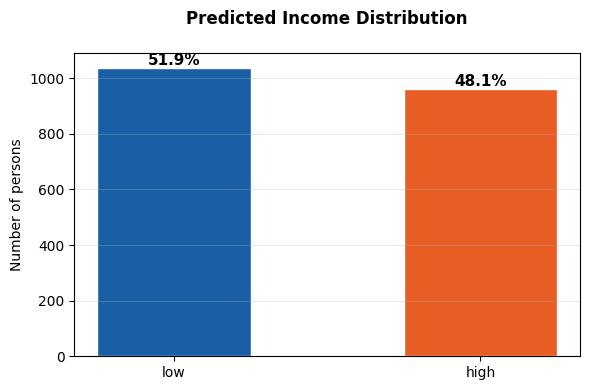

In [13]:


# count predictions
pred_counts = df_template['income'].value_counts()
pred_pct = df_template['income'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6,4))

bars = ax.bar(
    pred_counts.index,
    pred_counts.values,
    color=['#185FA5', '#E85D24'],
    edgecolor='white',
    width=0.5
)

for bar, pct in zip(bars, pred_pct):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{pct:.1f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax.set_title(
    'Predicted Income Distribution\n',
    fontweight='bold'
)

ax.set_ylabel('Number of persons')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(figures,
                 'predicted_income_distribution.png'),
    dpi=150,
    bbox_inches='tight'
)

plt.show()